In [29]:
import pandas as pd

import requests

import numpy as np

import random

# ዝርዝር መረጃዎች
diseases = ["Malaria", "Typhoid", "Hypertension", "Diabetes", "Common Cold"]
departments = ["Emergency", "emergency", "EMERGENCY", "Pediatrics", "PEDIATRICS", "ICU", "icu", "General Ward"]
cities = ["Addis Ababa", "Nazreth", "Hawassa", "Gondar", np.nan] # የጎደለ ከተማ አለው

rows=[]

for i in range(10000):
    age=random.choice([random.randint(1,85),-5,-12,210,350])
    disease=random.choice(diseases)
    dept=random.choice(departments)
    city=random.choice(cities)

    # የህክምና ክፍያ (Bill) ላይ "ETB" መጨመር እና አንዳንዱን NaN ማድረግ
    bill = random.choice([f"ETB {random.randint(1500, 75000):,}", np.nan])

    rows.append({
        "Patient_ID": 50000 + i,
        "Age": age,
        "Gender": random.choice(["M", "F"]),
        "Diagnosis": disease,
        "Department": dept,
        "City": city,
        "Hospital_Bill": bill
    })

df_health = pd.DataFrame(rows)
df_health.to_csv("messy_ethiopian_healthcare.csv", index=False)
# print("10,000 መስመር ያለው 'messy_ethiopian_healthcare.csv' በስኬት ተፈጥሯል!")

df=pd.read_csv("messy_ethiopian_healthcare.csv" , encoding="utf-8")
print(df.head())

df.loc[(df["Age"]<0) ,"Age"]=0

df.loc[(df["Age"]>120),"Age"]=np.nan

print(df["Age"].head())

df["Age"]=df["Age"].fillna(df["Age"].mean())

# df["Age"].dtype

df["Age"]=df["Age"].astype(int)

# print(df)

df["Department"]=df["Department"].str.title()
print(df["Department"])

df["Department"].isnull().sum()

df["City"]=df["City"].fillna("Unkown-City")

# print(df["City"].head(20))

df["Hospital_Bill"].isnull().sum()

df["Hospital_Bill"]=df["Hospital_Bill"].str.replace("ETB","")
df["Hospital_Bill"]=df["Hospital_Bill"].str.replace(",", "")

print(df["Hospital_Bill"].head())

df["Hospital_Bill"]=df["Hospital_Bill"].astype(float)

df["Hospital_Bill"]=df["Hospital_Bill"].fillna(df["Hospital_Bill"].mean())

print(df["Hospital_Bill"].head().round(2))

High_cost = df.groupby("Diagnosis")["Hospital_Bill"].mean()

print(("The disease that incurs the highest average medical cost.").upper())
print(High_cost)




   Patient_ID  Age Gender     Diagnosis  Department         City Hospital_Bill
0       50000  210      M  Hypertension   EMERGENCY       Gondar    ETB 53,934
1       50001  210      F       Malaria  Pediatrics  Addis Ababa    ETB 74,073
2       50002  -12      F       Malaria         icu      Nazreth           NaN
3       50003    6      F   Common Cold         icu      Nazreth           NaN
4       50004   -5      F  Hypertension   Emergency       Gondar    ETB 20,559
0    NaN
1    NaN
2    0.0
3    6.0
4    0.0
Name: Age, dtype: float64
0          Emergency
1         Pediatrics
2                Icu
3                Icu
4          Emergency
            ...     
9995             Icu
9996    General Ward
9997       Emergency
9998             Icu
9999    General Ward
Name: Department, Length: 10000, dtype: object
0     53934
1     74073
2       NaN
3       NaN
4     20559
Name: Hospital_Bill, dtype: object
0    53934.00
1    74073.00
2    38218.82
3    38218.82
4    20559.00
Name: Hospit


የሊንክዲን ምስል 'linkedin_healthcare_chart.png' በሚል ስም በስኬት ተቀምጧል!


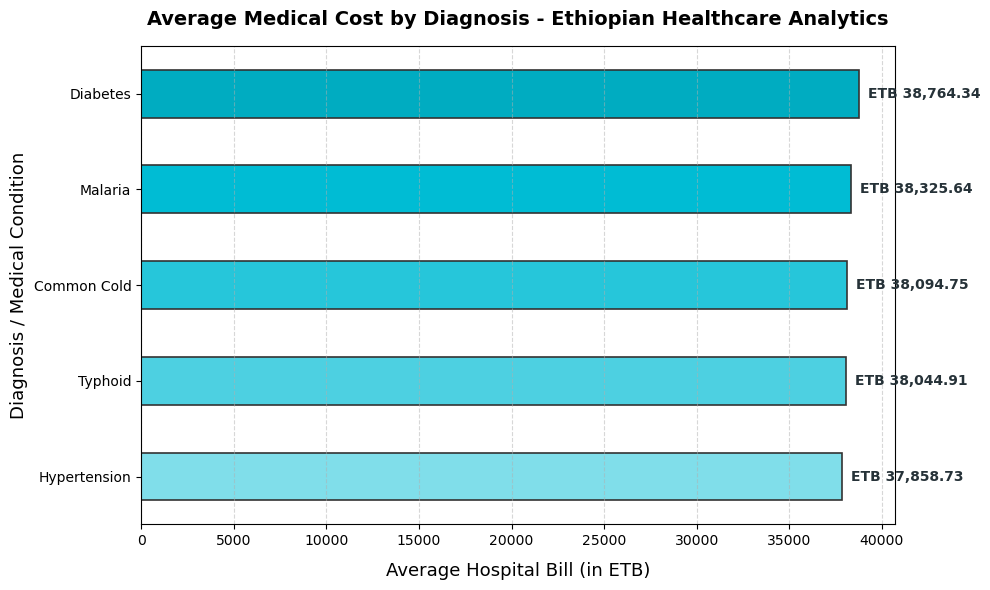

In [35]:
import matplotlib.pyplot as plt

# 1. ዳታውን በበሽታ ከፋፍሎ አማካኝ ወጪውን ማውጣት እና ከከፍተኛ ወደ ዝቅተኛ መደርደር
high_cost_sorted = df.groupby("Diagnosis")["Hospital_Bill"].mean().sort_values(ascending=True)

# 2. የምስሉን መጠን ለሊንክዲን ማስተካከል
plt.figure(figsize=(10, 6))

# 3. አግድም የባር ግራፍ መስራት (Horizontal Bar Chart)
# የሚያምር የጤና ዘርፍን የሚገልጽ የቱርኮይዝ/ሰማያዊ ቀለማት ስብስብ (Teal/Cyan gradient)
colors = ['#80deea', '#4dd0e1', '#26c6da', '#00bcd4', '#00acc1']
high_cost_sorted.plot(kind='barh', color=colors, edgecolor='#333333', linewidth=1.2)

# 4. የግራፉን ውበት ማስተካከል (Labels & Title)
plt.title("Average Medical Cost by Diagnosis - Ethiopian Healthcare Analytics", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Average Hospital Bill (in ETB)", fontsize=13, labelpad=10)
plt.ylabel("Diagnosis / Medical Condition", fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 5. በእያንዳንዱ ባር ጫፍ ላይ ትክክለኛውን የብር መጠን በፅሁፍ ማስቀመጥ
for index, value in enumerate(high_cost_sorted):
    plt.text(value + 500, index, f"ETB {value:,.2f}", va='center', fontsize=10, fontweight='bold', color='#263238')

# 6. ቁጥሮቹ ከምስሉ እንዳይወጡ ማድረግ
plt.tight_layout()

# 7. ምስሉን ለሊንክዲን ዝግጁ አድርጎ ሴቭ ማድረግ
plt.savefig("linkedin_healthcare_chart.png", dpi=300)
print("\nየሊንክዲን ምስል 'linkedin_healthcare_chart.png' በሚል ስም በስኬት ተቀምጧል!")